# Portfolio Risk & Performance Analysis
Quantitative portfolio optimization based on Modern Portfolio Theory (MPT).
Evaluates annual returns, annualized volatility, and maximum drawdown against the S&P 500 benchmark.

In [1]:
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr
import datetime as dt
import numpy as np

## Phase 1: Data Acquisition & Cumulative Log Returns

In [2]:
tickers = ["SPY", "BND", "GLD", "QQQ", "VTI"]

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days = 365*5)

In [3]:
# Datenimport
adj_close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = start_date, end = end_date)
    adj_close_df[ticker] = data["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
# Berechnung Tagesrenditen (Log-Returns)
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()

In [5]:
cumulative_log_returns = log_returns.cumsum()

<Axes: title={'center': 'Cumulative Returns'}, xlabel='Date'>

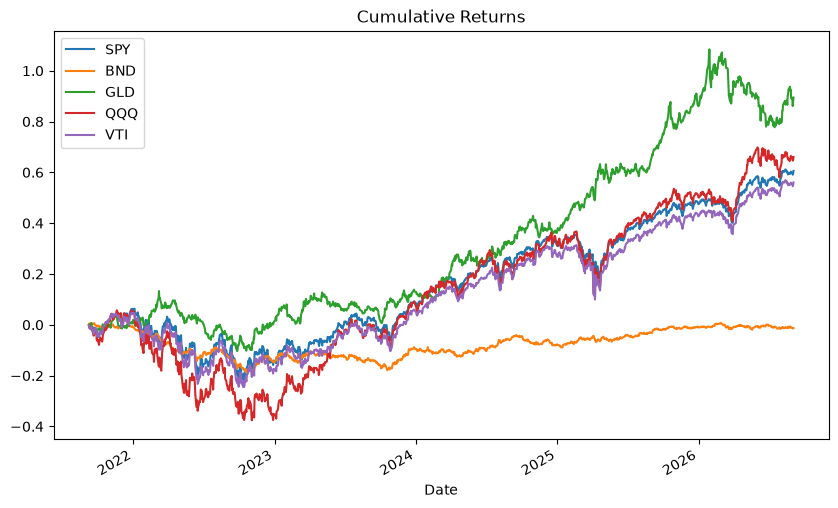

In [6]:
cumulative_log_returns.plot(title="Cumulative Returns", figsize=(10, 6))

## Phase 2: Portfolio Optimization (Markowitz MPT)

In [7]:
# Annualisierte Kovarianzmatrix (252 Handelstage)
cov_matrix = log_returns.cov() * 252
cov_matrix

,SPY,BND,GLD,QQQ,VTI
SPY,0.029538,0.002184,0.004776,0.037514,0.029999
BND,0.002184,0.003646,0.003392,0.002743,0.002299
GLD,0.004776,0.003392,0.035549,0.006339,0.005036
QQQ,0.037514,0.002743,0.006339,0.052780,0.038114
VTI,0.029999,0.002299,0.005036,0.038114,0.030726


In [8]:
# Hilfsfunktionen für Portfolio-Rendite, Volatilität & Sharpe Ratio
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights) * 252
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    p_returns, p_std_dev = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_returns - risk_free_rate) / p_std_dev

In [9]:
import scipy.optimize as sco

mean_returns = log_returns.mean()
num_assets = len(tickers)

# Optimierungsparameter: Summe Gewichte = 1, Long-Only (0 bis 1), Startwert: Gleichgewichtung
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1.0 / num_assets,]

# Maximierung der Sharpe Ratio (SLSQP-Optimizer)
opt_results = sco.minimize(
    negative_sharpe_ratio, 
    init_guess, 
    args=(mean_returns, cov_matrix), 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints)

optimal_weights = opt_results.x

for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.2%}")

SPY: 42.32%
BND: 0.00%
GLD: 57.68%
QQQ: 0.00%
VTI: 0.00%


## Phase 3: Benchmark Comparison & Downside Risk Analysis

In [10]:
opt_returns, opt_volatility = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_returns - 0.0) / opt_volatility

print(f"Erwartete annualisierte Rendite: {opt_returns:.2%}")
print(f"Annualisierte Volatilität (Risiko): {opt_volatility:.2%}")
print(f"Optimierte Sharpe Ratio: {opt_sharpe:.2f}")

Erwartete annualisierte Rendite: 15.53%
Annualisierte Volatilität (Risiko): 13.95%
Optimierte Sharpe Ratio: 1.11


In [11]:
# Maximalen kumulierten Verlust (Max Drawdown) berechnen
portfolio_daily_returns = (log_returns * optimal_weights).sum(axis=1)
portfolio_cum_returns = np.exp(portfolio_daily_returns.cumsum())

running_max = np.maximum.accumulate(portfolio_cum_returns)
drawdown = (portfolio_cum_returns - running_max) / running_max
max_drawdown = drawdown.min()
print(f"Max Drawdown des optimierten Portfolios: {max_drawdown:.2%}")

Max Drawdown des optimierten Portfolios: -17.95%


In [12]:
results_summary = pd.DataFrame({
    'Metric': ['Erwartete Rendite', 'Volatilität (Risiko)', 'Sharpe Ratio', 'Max Drawdown'],
    'Value': [
        f"{opt_returns:.2%}",
        f"{opt_volatility:.2%}",
        f"{opt_sharpe:.2f}",
        f"{max_drawdown:.2%}"]})
results_summary

,Metric,Value
0,Erwartete Rendite,15.53%
1,Volatilität (Risiko),13.95%
2,Sharpe Ratio,1.11
3,Max Drawdown,-17.95%


In [13]:
# Performance-Kennzahlen für den Benchmark (100% SPY)
spy_returns = mean_returns['SPY'] * 252
spy_volatility = np.sqrt(cov_matrix.loc['SPY', 'SPY'])
spy_sharpe = spy_returns / spy_volatility

spy_cum_returns = np.exp(log_returns['SPY'].cumsum())
spy_running_max = np.maximum.accumulate(spy_cum_returns)
spy_drawdown = (spy_cum_returns - spy_running_max) / spy_running_max
spy_max_drawdown = spy_drawdown.min()

# Vergleichstabelle erstellen
comparison_df = pd.DataFrame({
    'Metrik': ['Erwartete Rendite', 'Volatilität (Risiko)', 'Sharpe Ratio', 'Max Drawdown'],
    'Optimiertes Portfolio': [
        f"{opt_returns:.2%}",
        f"{opt_volatility:.2%}",
        f"{opt_sharpe:.2f}",
        f"{max_drawdown:.2%}"],
    'S&P 500 Benchmark (SPY)': [
        f"{spy_returns:.2%}",
        f"{spy_volatility:.2%}",
        f"{spy_sharpe:.2f}",
        f"{spy_max_drawdown:.2%}"]})
comparison_df

,Metrik,Optimiertes Portfolio,S&P 500 Benchmark (SPY)
0,Erwartete Rendite,15.53%,12.18%
1,Volatilität (Risiko),13.95%,17.19%
2,Sharpe Ratio,1.11,0.71
3,Max Drawdown,-17.95%,-24.50%


## Key Takeaways & Conclusion

* **Higher Risk-Adjusted Returns:** The optimized portfolio (42.32% SPY / 57.68% GLD) achieves a Sharpe Ratio of **1.11**, outperforming the S&P 500 benchmark (**0.71**).
* **Downside Protection:** Volatility is reduced from 17.19% to **13.95%**, while Maximum Drawdown improves from -24.50% to **-17.95%**.
* **Diversification Effect:** Low correlation between equity (SPY) and gold (GLD) successfully mitigates overall portfolio risk under Modern Portfolio Theory (MPT).